In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import nbformat, base64, re
from pathlib import Path
from scipy.integrate import quad
from scipy.interpolate import CubicSpline
import math

nb_file = "Ass4.ipynb"

# Load notebook
nb = nbformat.read(nb_file, as_version=4)

for cell in nb.cells:
    if cell.cell_type == "markdown":
        matches = re.findall(r'!\[\]\((.*?)\)', cell.source)
        for img_path in matches:
            path = Path(img_path)
            if path.exists():
                ext = path.suffix[1:]  # e.g., 'jpg' or 'png'
                data = base64.b64encode(path.read_bytes()).decode()
                img_tag = f'<img src="data:image/{ext};base64,{data}">'
                cell.source = cell.source.replace(f"![]({img_path})", img_tag)

# Save notebook with embedded images
nbformat.write(nb, "ee22b002_4.ipynb")


1. **Simpson’s rule accuracy**  
   Using the error analysis for the trapezoidal and rectangle rules, show that Simpson’s rule for integration over the entire interval is fourth-order accurate.

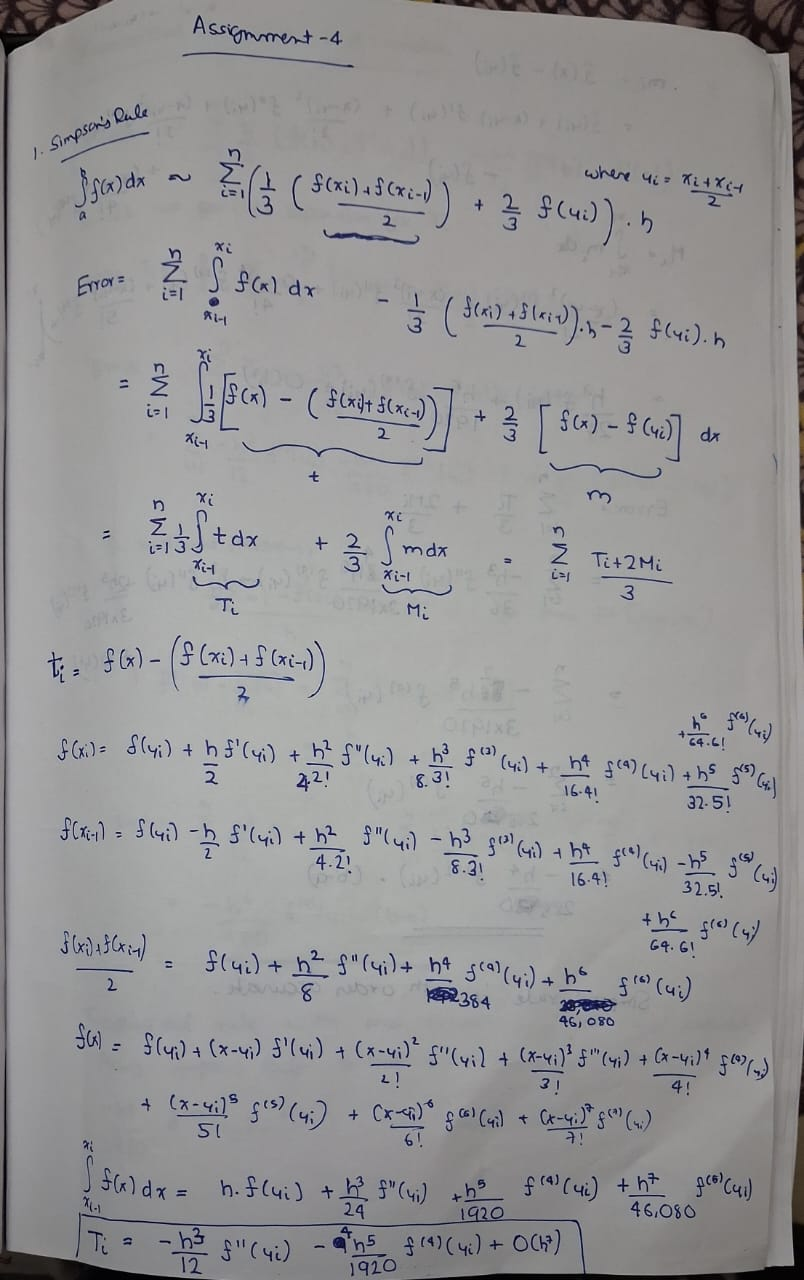

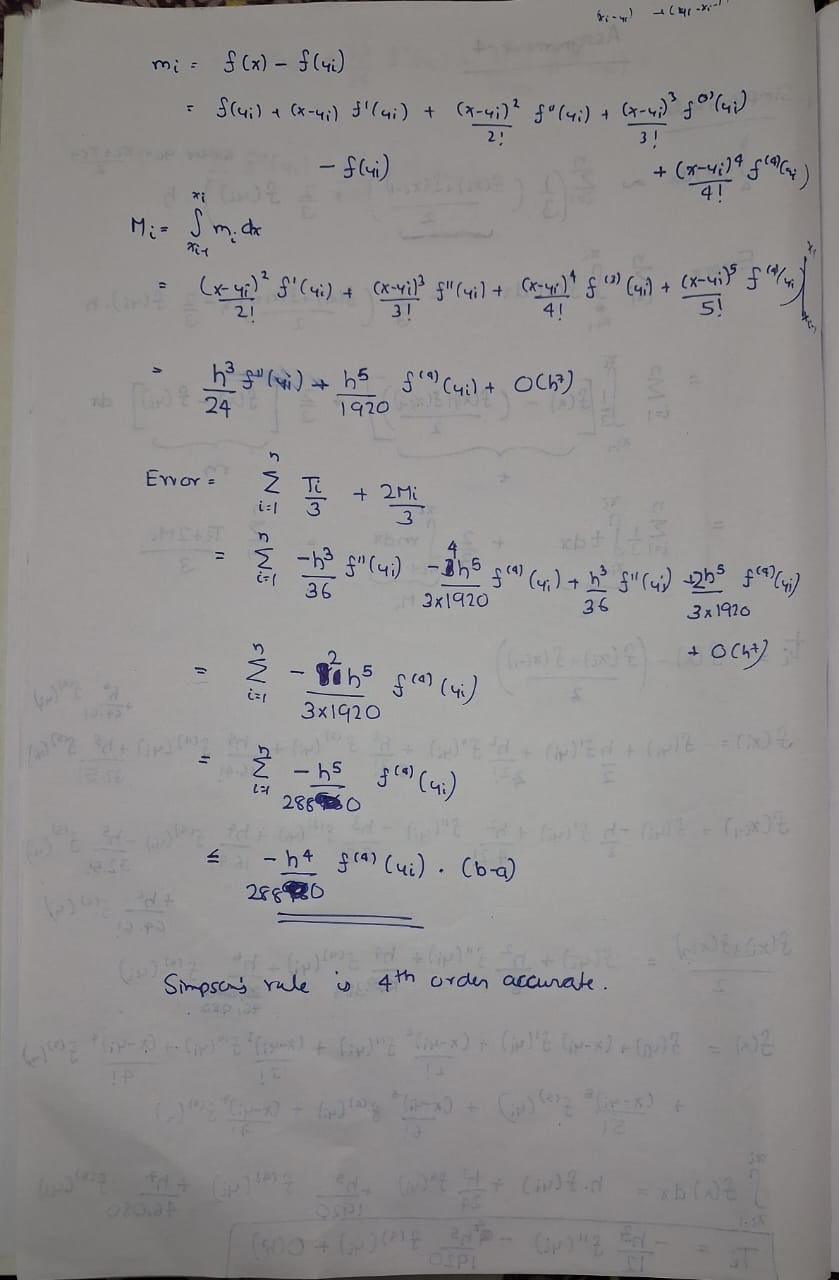

2. **Trapezoidal vs. Simpson’s rule**  
   Explain why the trapezoidal rule with end-correction is slightly more accurate than Simpson’s rule.

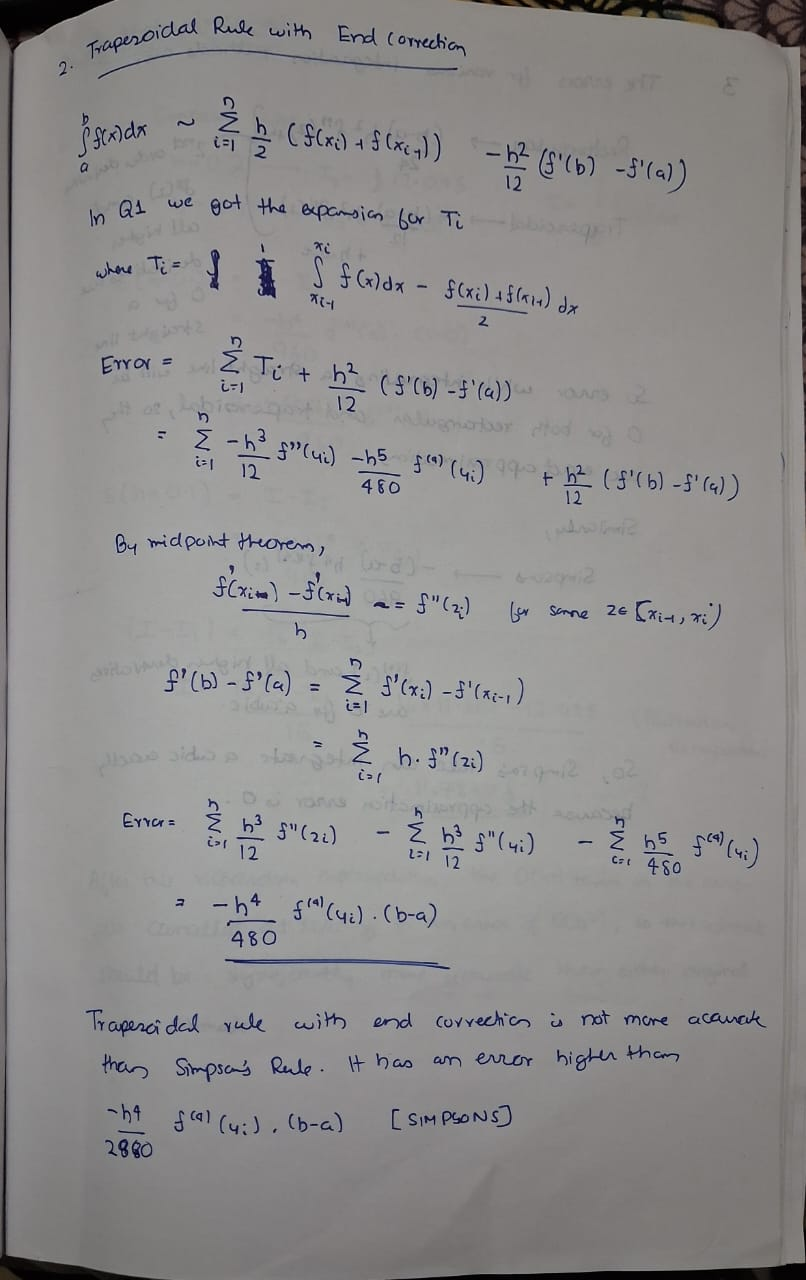

3. **Exact integration of polynomials**  
   Explain why the rectangle and trapezoidal rules can integrate a straight line exactly and the Simpson’s rule can integrate a cubic exactly.

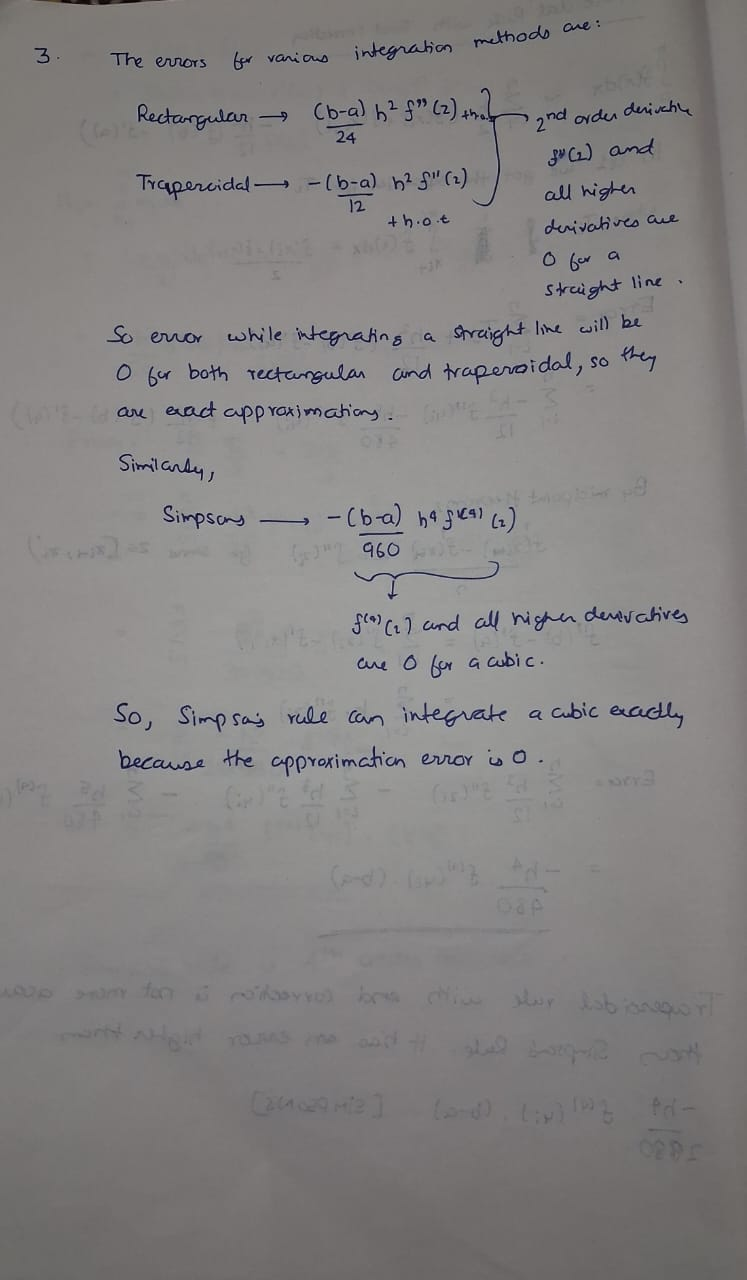

4. **Fredholm integral equation**  
   A common problem of mathematical physics is that of solving the Fredholm integral equation  
   $$
   f(x) = \phi(x) + \int_a^b K(x,t)\phi(t) \, dt
   $$
   where the functions $ f(x) $ and $ K(x,t) $ are given and the problem is to obtain $ \phi(x) $.  
   (a) Describe a numerical method for solving this equation.  
   (b) Solve the following equation  
   $$
   \phi(x) = \pi x^2 + \int_0^\pi 3(0.5 \sin 3x - tx^2)\phi(t) \, dt
   $$
   Compare to the exact solution $ \phi(x) = \sin 3x $.

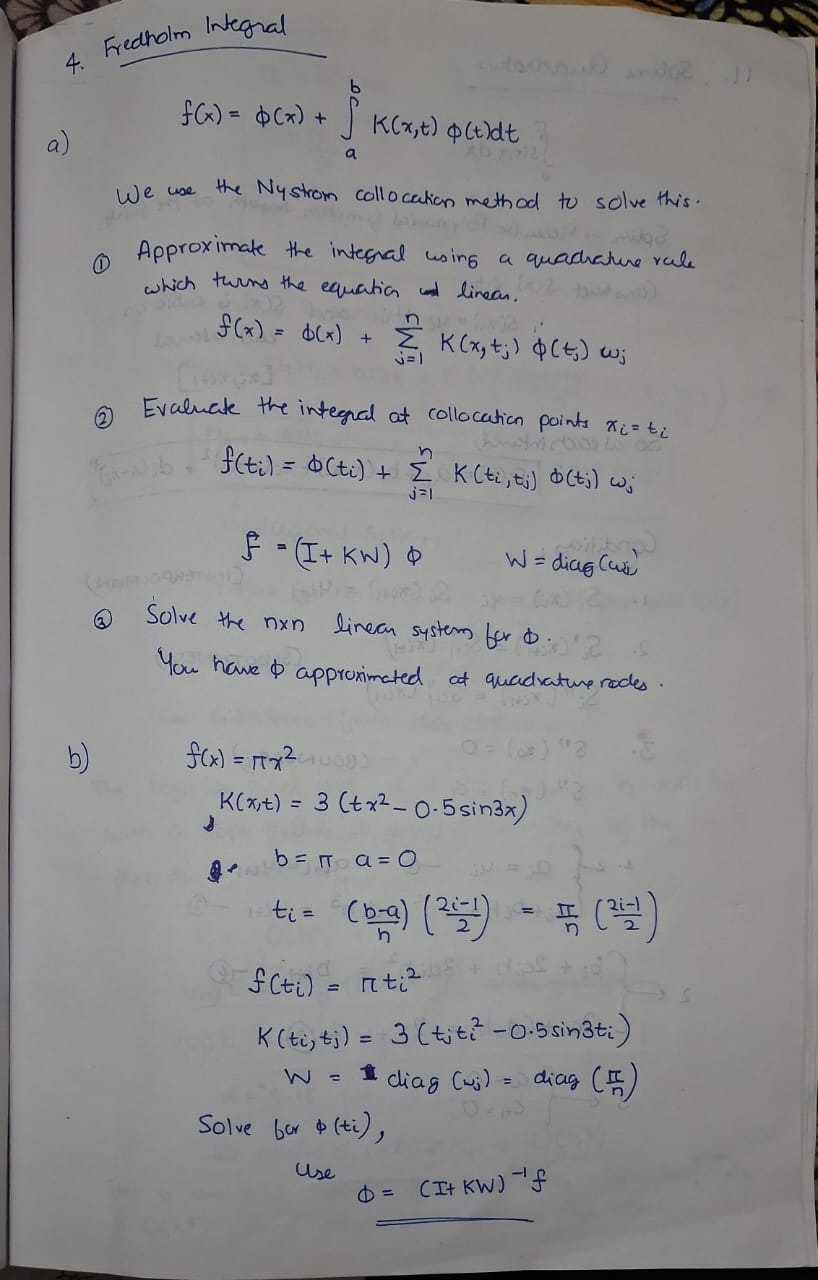

Quadrature points (t_i):
[0.0785 0.2356 0.3927 0.5498 0.7069 0.8639 1.021  1.1781 1.3352 1.4923
 1.6493 1.8064 1.9635 2.1206 2.2777 2.4347 2.5918 2.7489 2.906  3.0631]

Approximated φ(t_i):
[ 0.234577  0.652573  0.928279  1.001582  0.856484  0.524588  0.078211
 -0.385383 -0.76518  -0.978443 -0.978741 -0.766075 -0.386873  0.076124
  0.521906  0.853206  0.997708  0.923808  0.647505  0.228913]

Exact φ(t_i) = sin(3x):
[ 0.233445  0.649448  0.92388   0.996917  0.85264   0.522499  0.078459
 -0.382683 -0.760406 -0.97237  -0.97237  -0.760406 -0.382683  0.078459
  0.522499  0.85264   0.996917  0.92388   0.649448  0.233445]

Absolute error:
[1.131e-03 3.125e-03 4.399e-03 4.665e-03 3.844e-03 2.090e-03 2.480e-04
 2.699e-03 4.774e-03 6.073e-03 6.371e-03 5.669e-03 4.190e-03 2.335e-03
 5.930e-04 5.660e-04 7.900e-04 7.200e-05 1.943e-03 4.532e-03]

Max error = 6.371e-03,  L2 error = 3.603e-03


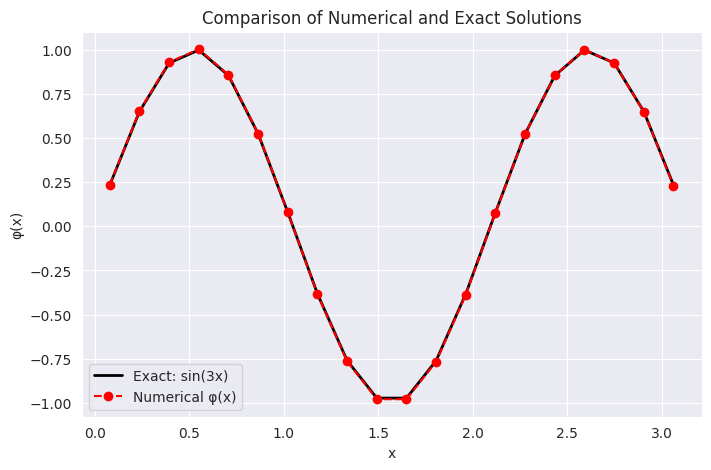

In [3]:
def f(x):
    return np.pi * x**2

def K(x, t):
    return 3 * (t * x**2 - 0.5 * np.sin(3 * x))

def phi_exact(x):
    return np.sin(3 * x)

n = 20
a, b = 0, np.pi
h = (b - a) / n

# Midpoint quadrature points and weights
t = a + h * (np.arange(1, n + 1) - 0.5)
w = np.full(n, h)

K_mat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        K_mat[i, j] = K(t[i], t[j])

I = np.eye(n)
W = np.diag(w)

A = I + K_mat @ W
b_vec = f(t)
phi_num = np.linalg.solve(A, b_vec)
phi_ex = phi_exact(t)

print("Quadrature points (t_i):")
print(np.round(t, 4))
print("\nApproximated φ(t_i):")
print(np.round(phi_num, 6))
print("\nExact φ(t_i) = sin(3x):")
print(np.round(phi_ex, 6))
print("\nAbsolute error:")
print(np.round(np.abs(phi_num - phi_ex), 6))

# Compute error norms
err_max = np.max(np.abs(phi_num - phi_ex))
err_L2 = np.sqrt(np.mean((phi_num - phi_ex)**2))
print(f"\nMax error = {err_max:.3e},  L2 error = {err_L2:.3e}")

# --- Plot comparison ---
plt.figure(figsize=(8,5))
plt.plot(t, phi_ex, 'k-', lw=2, label='Exact: sin(3x)')
plt.plot(t, phi_num, 'ro--', label='Numerical φ(x)')
plt.title('Comparison of Numerical and Exact Solutions')
plt.xlabel('x')
plt.ylabel('φ(x)')
plt.legend()
plt.grid(True)
plt.show()

5. **Singular integral**  
   $$
   \int_0^1 \left[ \frac{100}{\sqrt{x + 0.01}} + \frac{1}{(x - 0.3)^2 + 0.001} - \pi \right] dx
   $$  
   (a) Use the trapezoidal rule with $n$ panels of equal size and plot log–log of error vs. $ n = 8, 16, 32, \ldots $. Discuss the accuracy of the method.
   
   (b) Repeat using Simpson’s rule and trapezoidal rule with end-correction.

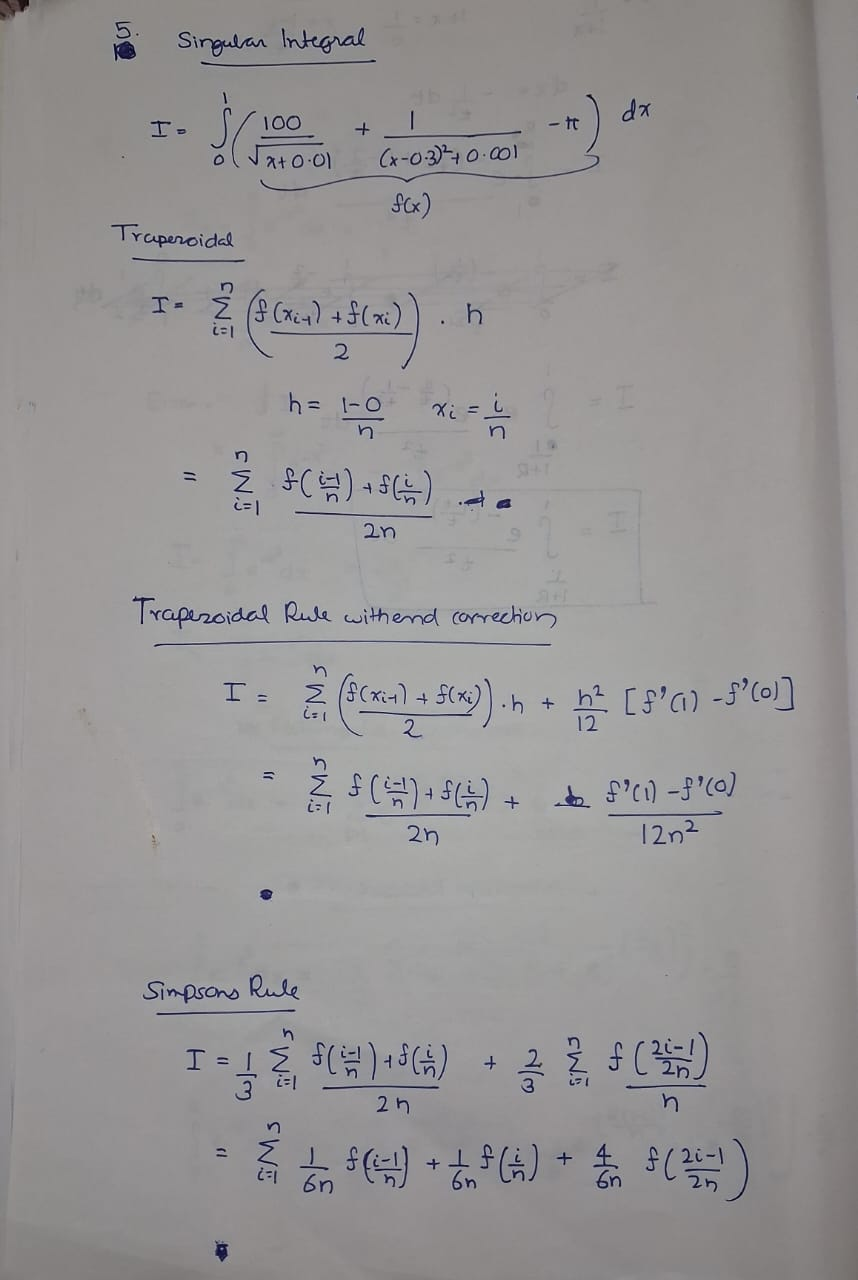

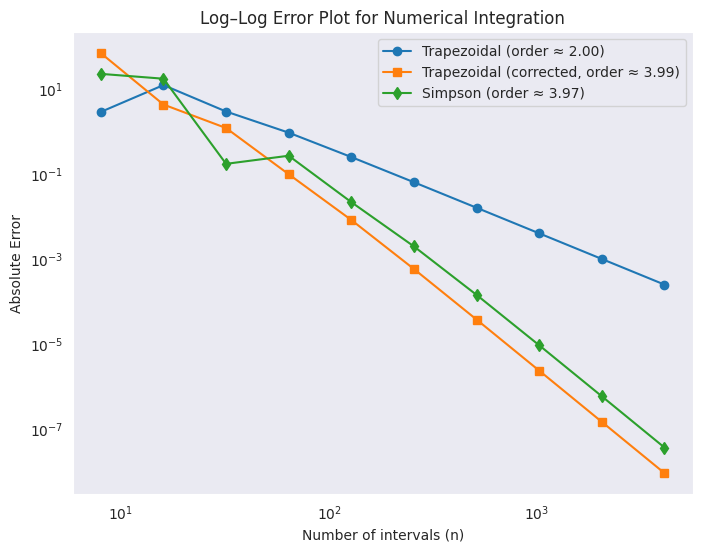

Exact Integral = 272.45313232
n=8     | Trap Err=2.818e+00 | Corr Err=6.776e+01 | Simp Err=2.207e+01
n=16    | Trap Err=1.203e+01 | Corr Err=4.204e+00 | Simp Err=1.698e+01
n=32    | Trap Err=2.880e+00 | Corr Err=1.178e+00 | Simp Err=1.700e-01
n=64    | Trap Err=9.178e-01 | Corr Err=9.691e-02 | Simp Err=2.636e-01
n=128   | Trap Err=2.455e-01 | Corr Err=8.159e-03 | Simp Err=2.142e-02
n=256   | Trap Err=6.284e-02 | Corr Err=5.755e-04 | Simp Err=1.952e-03
n=512   | Trap Err=1.582e-02 | Corr Err=3.737e-05 | Simp Err=1.420e-04
n=1024  | Trap Err=3.961e-03 | Corr Err=2.360e-06 | Simp Err=9.310e-06
n=2048  | Trap Err=9.907e-04 | Corr Err=1.479e-07 | Simp Err=5.895e-07
n=4096  | Trap Err=2.477e-04 | Corr Err=9.250e-09 | Simp Err=3.697e-08


In [4]:
def f(x):
    return 100 / np.sqrt(x + 0.01) + 1 / ((x - 0.3)**2 + 0.001) - np.pi

def f_prime(x):
    return -50 * (x + 0.01)**(-1.5) - 2 * (x - 0.3) / ((x - 0.3)**2 + 0.001)**2

def exact_integral():
    term1 = 200 * (np.sqrt(1.01) - np.sqrt(0.01))
    term2 = (1 / np.sqrt(0.001)) * (
        np.arctan((1 - 0.3) / np.sqrt(0.001)) - np.arctan((0 - 0.3) / np.sqrt(0.001))
    )
    term3 = -np.pi
    return term1 + term2 + term3

I_exact = exact_integral()

def trapezoidal(f, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])

def trapezoidal_corrected(f, f_prime, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    correction = (h**2 / 12) * (f_prime(b) - f_prime(a))
    return (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1]) - correction

def simpson(f, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return (h / 3) * (y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2]) + y[-1])


a, b = 0, 1
n_values = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

errors_trap = []
errors_trap_corr = []
errors_simp = []

for n in n_values:
    I_t = trapezoidal(f, a, b, n)
    I_tc = trapezoidal_corrected(f, f_prime, a, b, n)
    I_s = simpson(f, a, b, n)
    errors_trap.append(abs(I_t - I_exact))
    errors_trap_corr.append(abs(I_tc - I_exact))
    errors_simp.append(abs(I_s - I_exact))


def estimate_order(errors, ns):
    e = np.array(errors)
    n = np.array(ns)
    p = np.polyfit(np.log2(n[-4:]), np.log2(e[-4:]), 1)[0]
    return -p

p_trap = estimate_order(errors_trap, n_values)
p_corr = estimate_order(errors_trap_corr, n_values)
p_simp = estimate_order(errors_simp, n_values)
import seaborn as sns
sns.set_style('dark')
plt.figure(figsize=(8,6))
plt.loglog(n_values, errors_trap, 'o-', label=f'Trapezoidal (order ≈ {p_trap:.2f})')
plt.loglog(n_values, errors_trap_corr, 's-', label=f'Trapezoidal (corrected, order ≈ {p_corr:.2f})')
plt.loglog(n_values, errors_simp, 'd-', label=f'Simpson (order ≈ {p_simp:.2f})')
plt.xlabel("Number of intervals (n)")
plt.ylabel("Absolute Error")
plt.title("Log–Log Error Plot for Numerical Integration")
plt.legend()
plt.show()

print(f"Exact Integral = {I_exact:.8f}")
for n, e1, e2, e3 in zip(n_values, errors_trap, errors_trap_corr, errors_simp):
    print(f"n={n:<5} | Trap Err={e1:.3e} | Corr Err={e2:.3e} | Simp Err={e3:.3e}")

6. **Refinement using two estimates**  
   Simpson’s rule was used for $ \int_0^1 f(x) dx $:  
   - $ h = 0.2 \rightarrow I = 12.045 $  
   - $ h = 0.1 \rightarrow I = 11.801 $  
   Use this info to get a more accurate value.

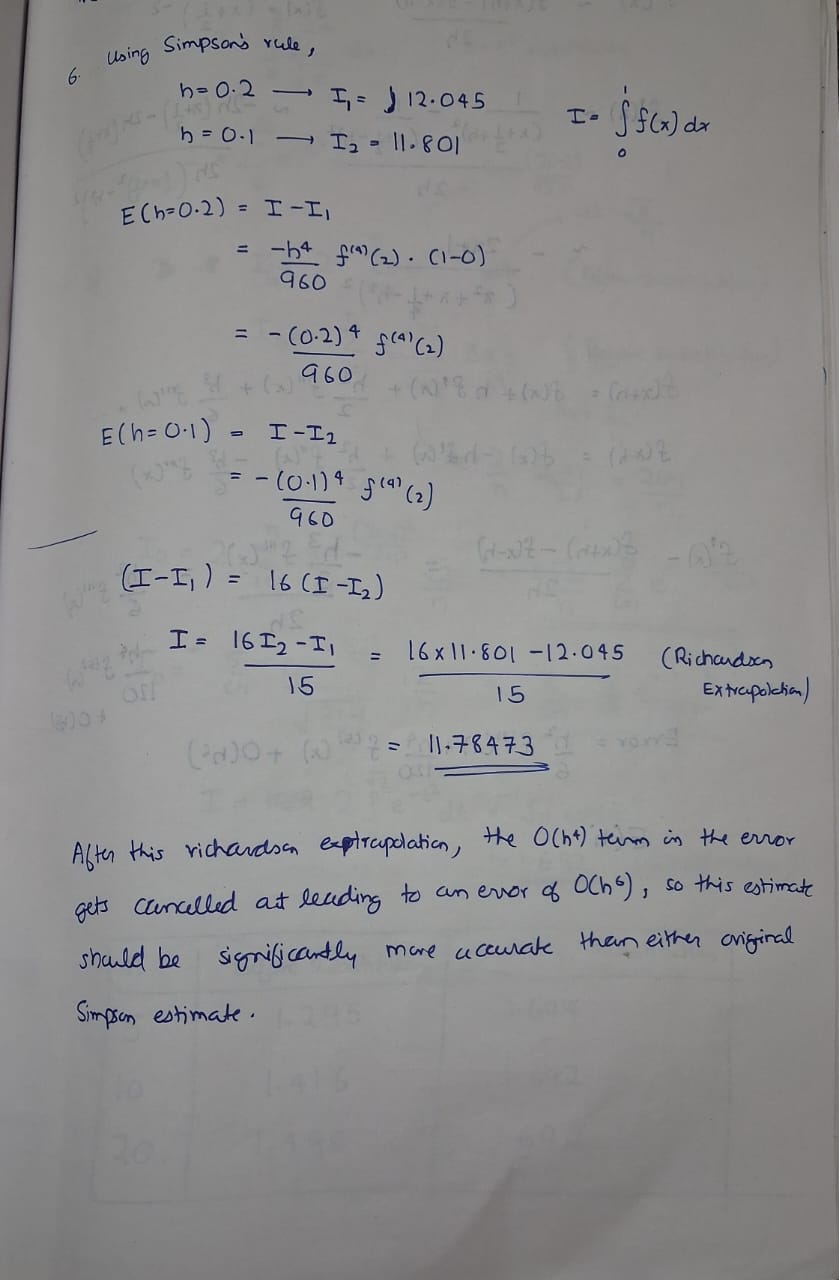

7. **Richardson extrapolation**  
    Compute $ f'(1.0) $ and $ f'(5.0) $ to 5-place accuracy using  
    $$
    f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}, \quad f(x) = (x + 0.5)^{-2}, \quad h_0 = 0.5
    $$  
    Comment on convergence differences.

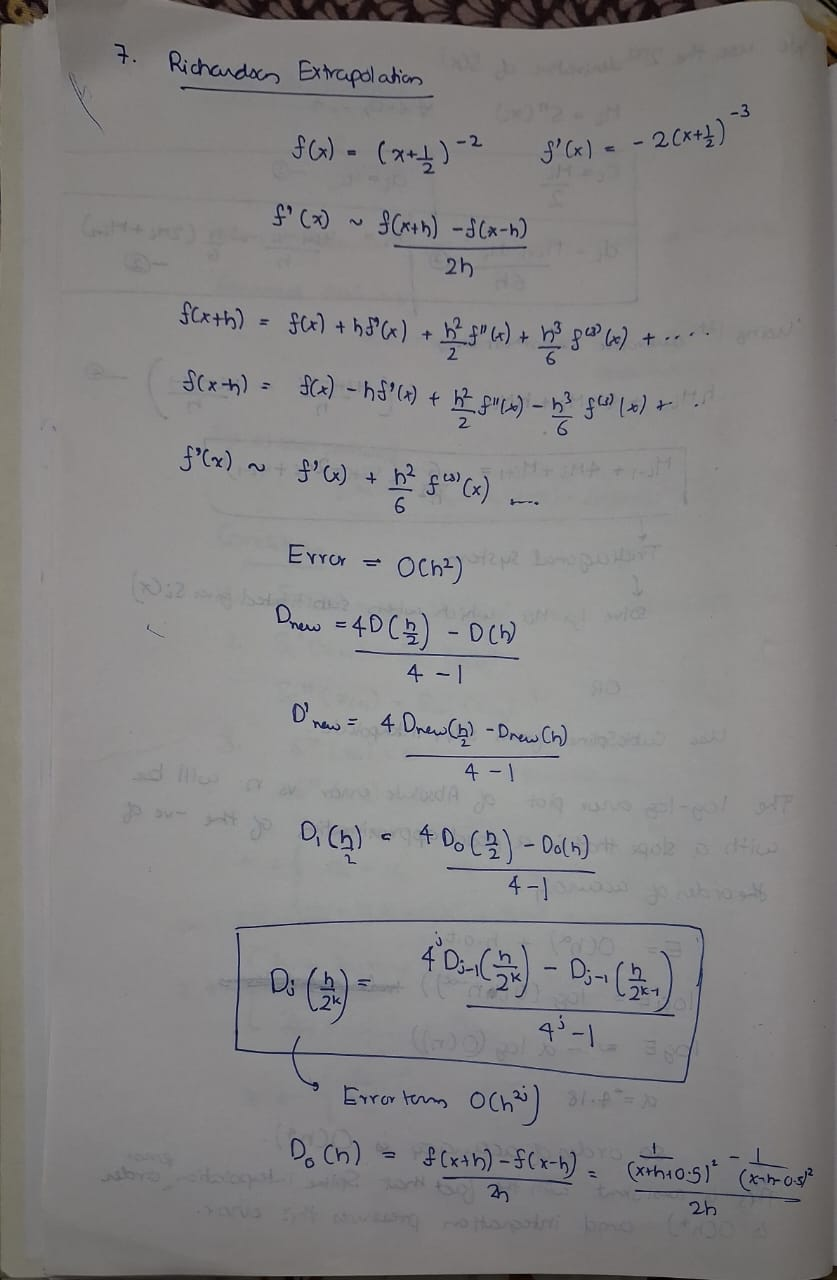

In [5]:
import numpy as np
import pandas as pd

def f(x):
    return (x+1/2)**-2

def f_prime(x):
    return -2*(x+1/2)**-3

def central_diff(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

def richardson_derivative(f, x, h0, levels=5):
    D = np.zeros((levels, levels))
    h = np.zeros(levels)

    for k in range(levels):
        h[k] = h0 / (2**k)
        D[k, 0] = (f(x + h[k]) - f(x - h[k])) / (2 * h[k])
    for j in range(1, levels):
        for k in range(j, levels):
            D[k, j] = D[k, j-1] + (D[k, j-1] - D[k-1, j-1]) / (4**j - 1)

    return D, h

for x in [1.0, 5.0]:
    D, h = richardson_derivative(f, x, 0.5, levels=5)
    approx = D[-1, -1]
    exact = f_prime(x)
    print(f"x = {x}")
    print(f"  Approx derivative = {approx:.8f}")
    print(f"  Exact derivative  = {exact:.8f}")
    print(f"  Absolute error    = {abs(approx - exact):.2e}\n")

x = 1.0
  Approx derivative = -0.59259259
  Exact derivative  = -0.59259259
  Absolute error    = 6.89e-11

x = 5.0
  Approx derivative = -0.01202104
  Exact derivative  = -0.01202104
  Absolute error    = 9.89e-17



8. **Gauss quadrature**  
    Evaluate  
    $$
    I = \int_{-\infty}^{\infty} e^{-x^2} \cos(\alpha x) dx
    $$  
    for $ \alpha = 5 $. Exact solution: $ \sqrt{\pi}e^{-\alpha^2/4} $. Discuss the number of function evaluations required.

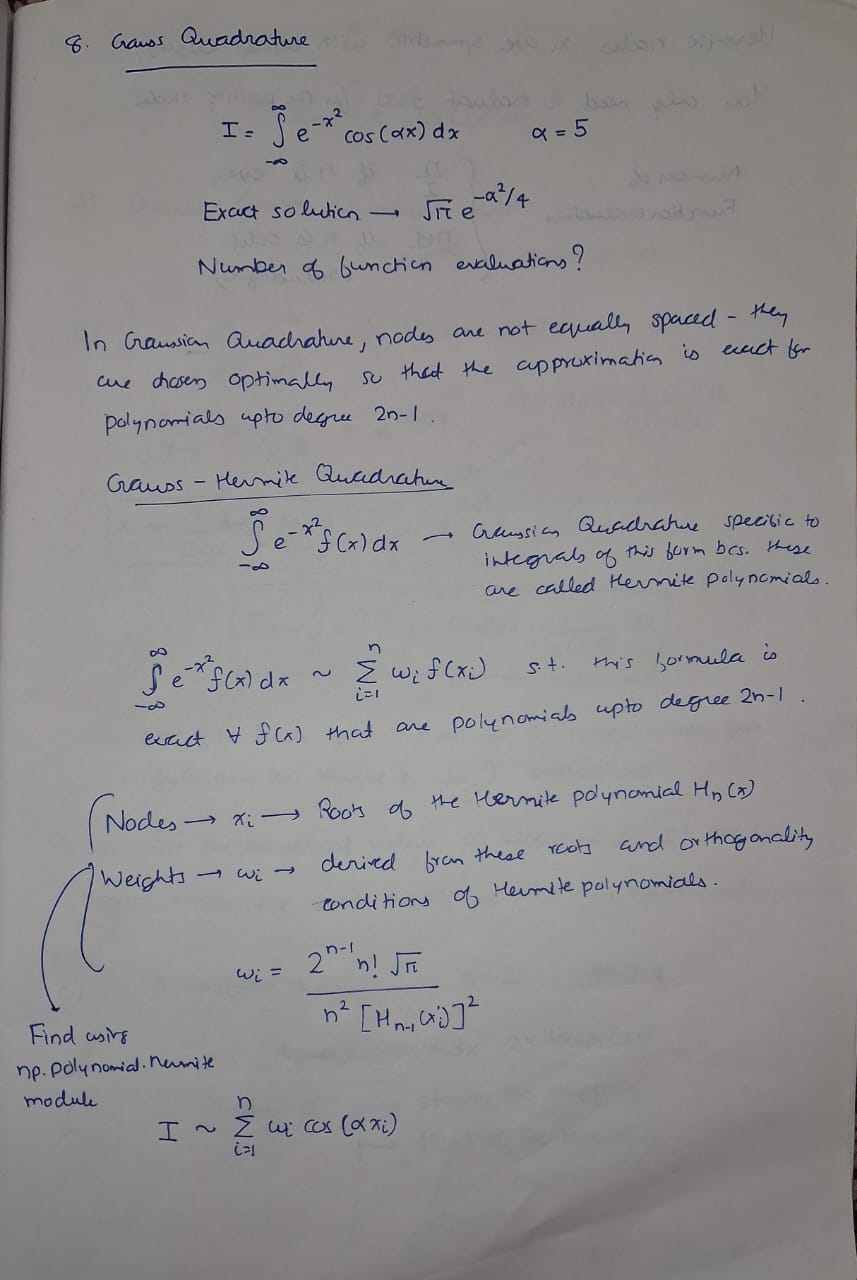

In [6]:
import numpy as np
from math import sqrt, pi, exp, cos

def gauss_hermite_integral(alpha, n=16):

    x, w = np.polynomial.hermite.hermgauss(n)
    fx = np.cos(alpha * x)
    approx = np.sum(w * fx)
    exact = sqrt(pi) * exp(-alpha**2 / 4)
    abs_error = abs(approx - exact)

    return approx, exact, abs_error


alpha = 5
for n in [4, 8, 16, 24, 32]:
    approx, exact, err = gauss_hermite_integral(alpha, n)
    print(f"n = {n:<3d}  Approx = {approx:.8e}  Error = {err:.2e}")


n = 4    Approx = -1.46159645e+00  Error = 1.47e+00
n = 8    Approx = -1.00059733e-01  Error = 1.03e-01
n = 16   Approx = 3.41925488e-03  Error = 2.39e-06
n = 24   Approx = 3.42164087e-03  Error = 8.72e-13
n = 32   Approx = 3.42164087e-03  Error = 1.62e-16


9. **Singularity handling**  
    Evaluate  
    $$
    I = \int_0^2 \frac{e^{-x}}{\sqrt{x}} dx
    $$  
    (a) Substitute $ x = t^2 $  
    (b) Use midpoint rule and compute the integral before and after the change of variable. Comment on the accuracy and cost.

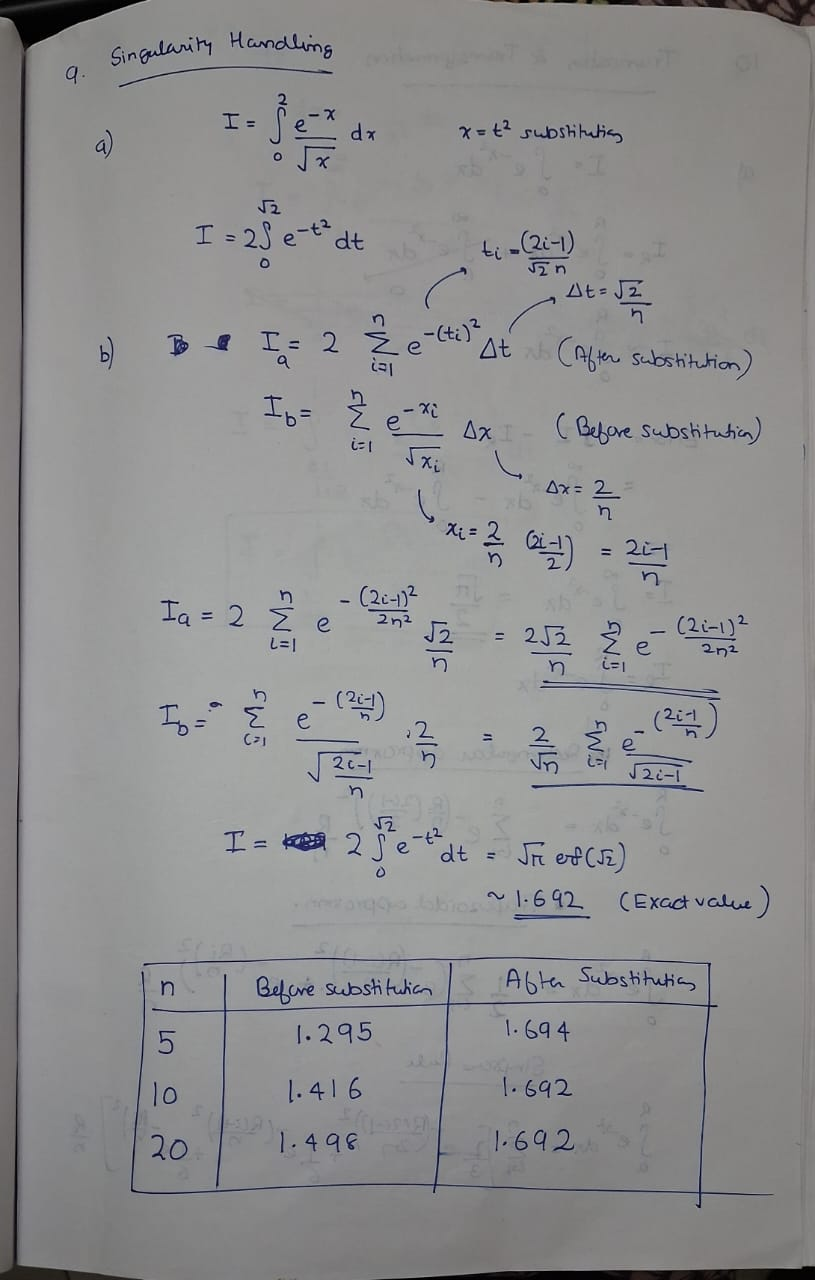

In [7]:
I_exact = np.sqrt(np.pi) * math.erf(np.sqrt(2))
print(f"Exact value: {I_exact:.6f}")

def I_after(n):
    i = np.arange(1, n+1)
    x_mid = (2*i - 1) * np.sqrt(2) / (2*n)
    return (2 * np.sqrt(2) / n) * np.sum(np.exp(-x_mid**2))

def I_before(n):
    i = np.arange(1, n+1)
    t_mid = (2*i - 1) / n
    return (2 / n) * np.sum(np.exp(-t_mid) / np.sqrt(t_mid))

for n in [5, 10, 20]:
    Ib = I_before(n)
    Ia = I_after(n)
    print(f"\nn = {n}")
    print(f"Before substitution: {Ib:.6f}  (Error: {abs(Ib - I_exact):.6f})")
    print(f"After substitution:  {Ia:.6f}  (Error: {abs(Ia - I_exact):.6f})")


Exact value: 1.691807

n = 5
Before substitution: 1.295500  (Error: 0.396307)
After substitution:  1.694346  (Error: 0.002540)

n = 10
Before substitution: 1.416192  (Error: 0.275615)
After substitution:  1.692444  (Error: 0.000637)

n = 20
Before substitution: 1.498672  (Error: 0.193135)
After substitution:  1.691966  (Error: 0.000159)


10. **Truncation and transformation**  
    Evaluate  
    $$I = \int_0^{\infty} e^{-x^2} dx$$
    (a) One can truncate the integration range to a fnite interval, $[0,R]$ such that the integral from $R$ to $\infty$ is "sufficiently small". Approximate $\int_0^{\infty} e^{-x^2} dx$ using $\int_0^{R} e^{-x^2} dx$ and get a bound on the error as a function of $R$. For $R=4$, evaluate $\int_0^{R} e^{-x^2} dx$ using an appropriate quadrature and use to approximate $\int_0^{\infty} e^{-x^2} dx$. Obtain the bound on the error and compare it with the actual error.               
    (b) Change variable $ t = 1/(1+x) $ and use an appropriate quadrature. Compare with exact: $ \sqrt{\pi}/2 $

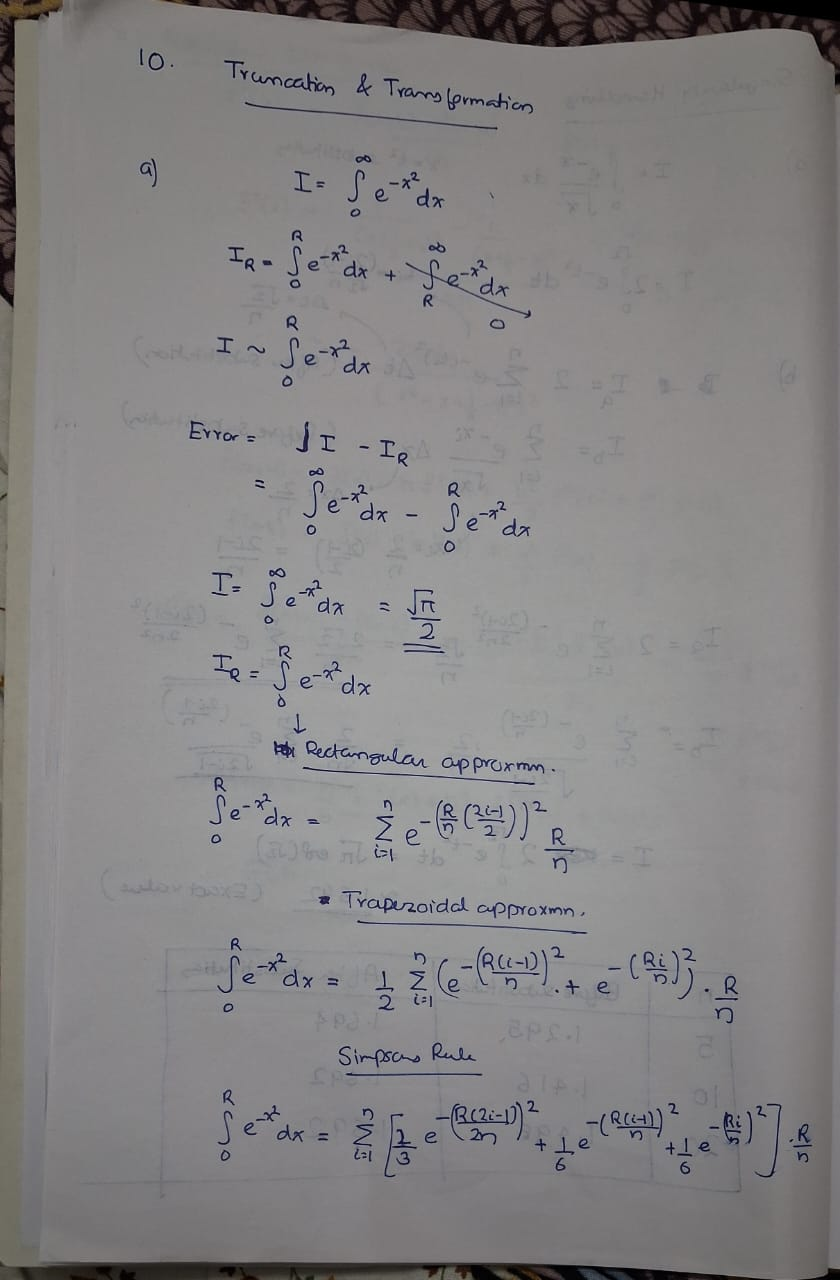

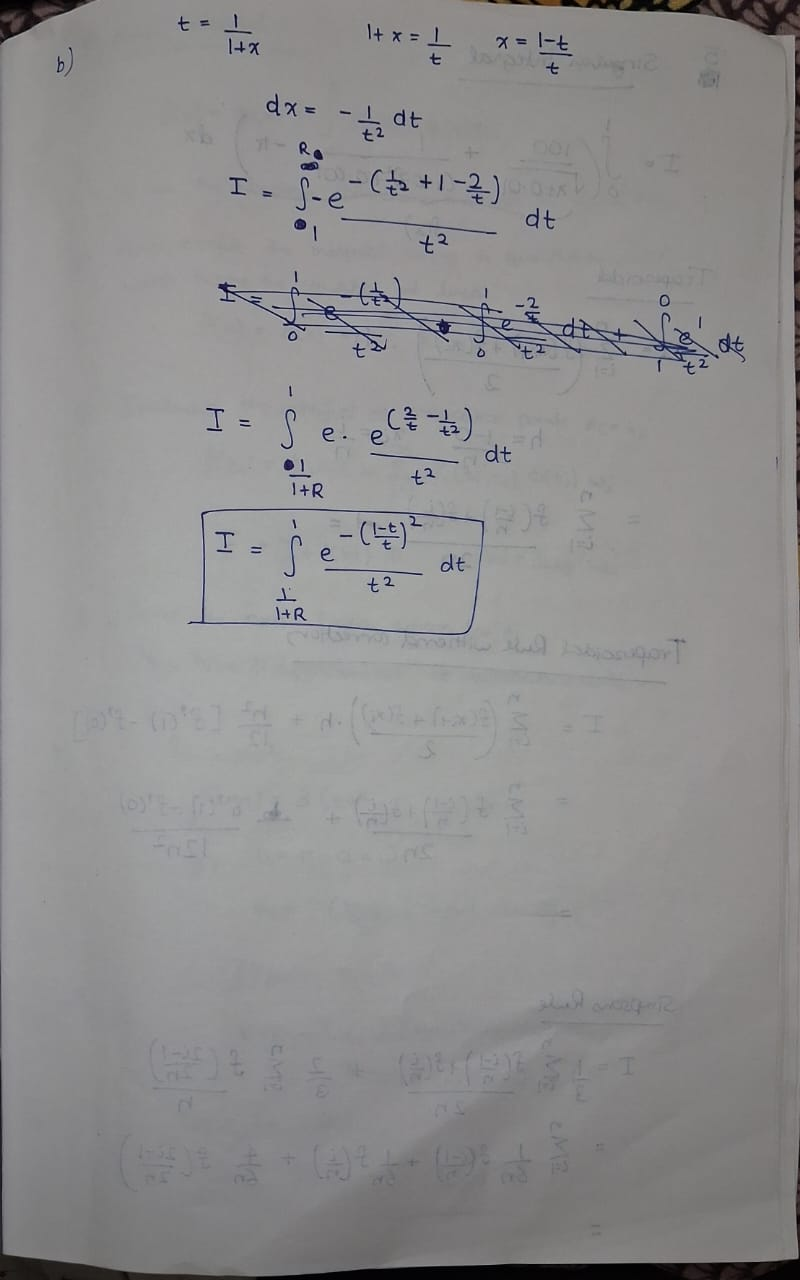

In [8]:
def exact_integral(R):
    return sqrt(pi) * math.erf(R) / 2

def f_t(t):
    return np.exp(-((1 - t) / t) ** 2) / (t ** 2)

# Rectangular rule after substitution
def rectangular_sub(R, n):
    a, b = 1 / (1 + R), 1
    dt = (b - a) / n
    t_mid = a + (np.arange(1, n + 1) - 0.5) * dt
    return np.sum(f_t(t_mid)) * dt

# Trapezoidal rule after substitution
def trapezoidal_sub(R, n):
    a, b = 1 / (1 + R), 1
    dt = (b - a) / n
    t = np.linspace(a, b, n + 1)
    f = f_t(t)
    return np.sum((f[:-1] + f[1:]) / 2) * dt

# Simpson's rule after substitution
def simpson_sub(R, n):
    a, b = 1 / (1 + R), 1
    dt = (b - a) / n
    t_left = a + (np.arange(1, n + 1) - 1) * dt
    t_right = a + np.arange(1, n + 1) * dt
    t_mid = a + (np.arange(1, n + 1) - 0.5) * dt
    return np.sum(
        (2/3)*f_t(t_mid) + (1/6)*f_t(t_left) + (1/6)*f_t(t_right)
    ) * dt

R_values = [1, 2,3,4,5]
n = 100

print(f"{'R':>3} | {'Rectangular':>12} | {'Trapezoidal':>12} | {'Simpson':>12} | {'Approximation (R)':>12}| {'Exact Value':>12}")
print("-" * 80)

for R in R_values:
    rect = rectangular_sub(R, n)
    trap = trapezoidal_sub(R, n)
    simp = simpson_sub(R, n)
    exact = exact_integral(R)
    exact_value = np.sqrt(np.pi)/2
    print(f"{R:>3} | {rect:>12.6f} | {trap:>12.6f} | {simp:>12.6f} | {exact:>17.6f}| {exact_value:>12.6f}")

  R |  Rectangular |  Trapezoidal |      Simpson | Approximation (R)|  Exact Value
--------------------------------------------------------------------------------
  1 |     0.746832 |     0.746808 |     0.746824 |          0.746824|     0.886227
  2 |     0.882094 |     0.882056 |     0.882081 |          0.882081|     0.886227
  3 |     0.886212 |     0.886197 |     0.886207 |          0.886207|     0.886227
  4 |     0.886232 |     0.886216 |     0.886227 |          0.886227|     0.886227
  5 |     0.886233 |     0.886215 |     0.886227 |          0.886227|     0.886227


11. **Spline quadrature**  
    Evaluate  
    $$
    \int_0^\pi \sin(x) dx
    $$  
    (a) Use cubic spline interpolation  
    (b) Use 4, 8, 16, 32 intervals. Plot log–log error vs. points. Determine accuracy order.

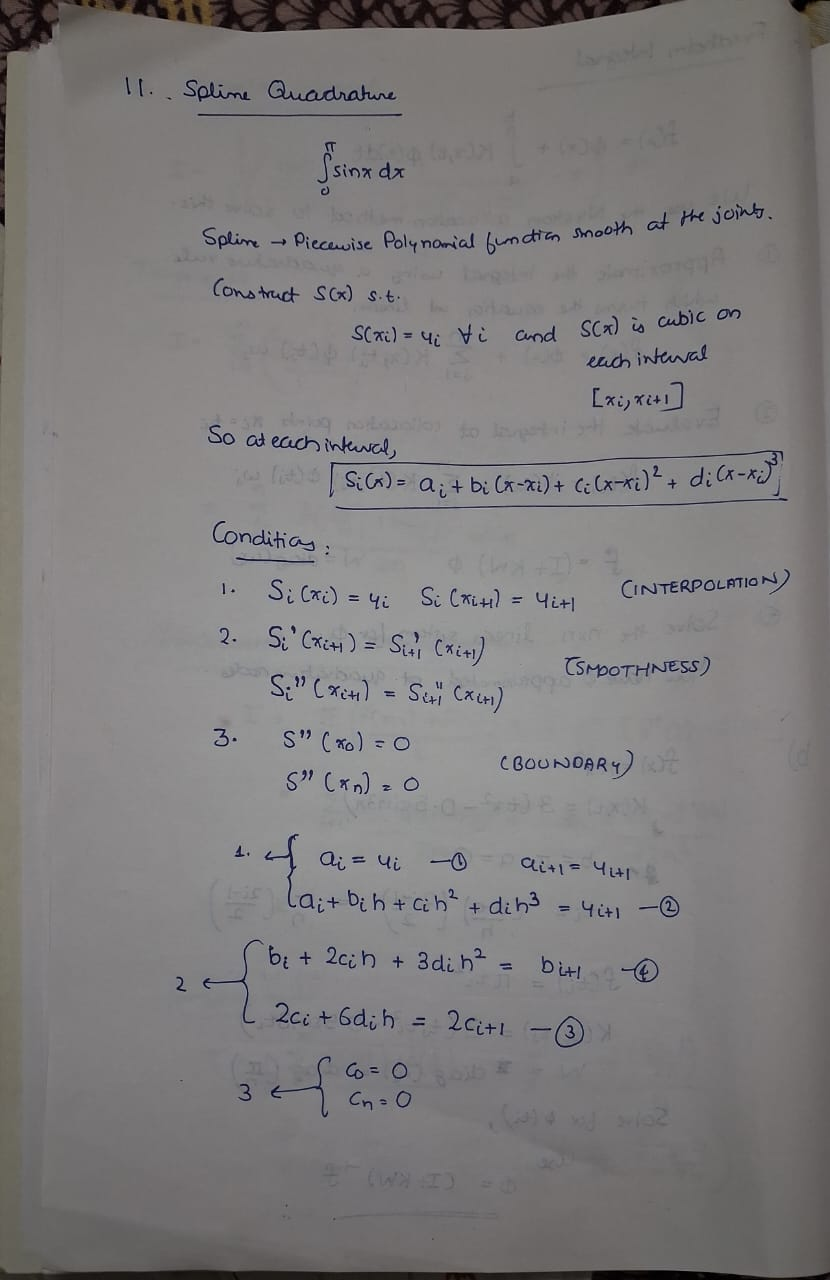

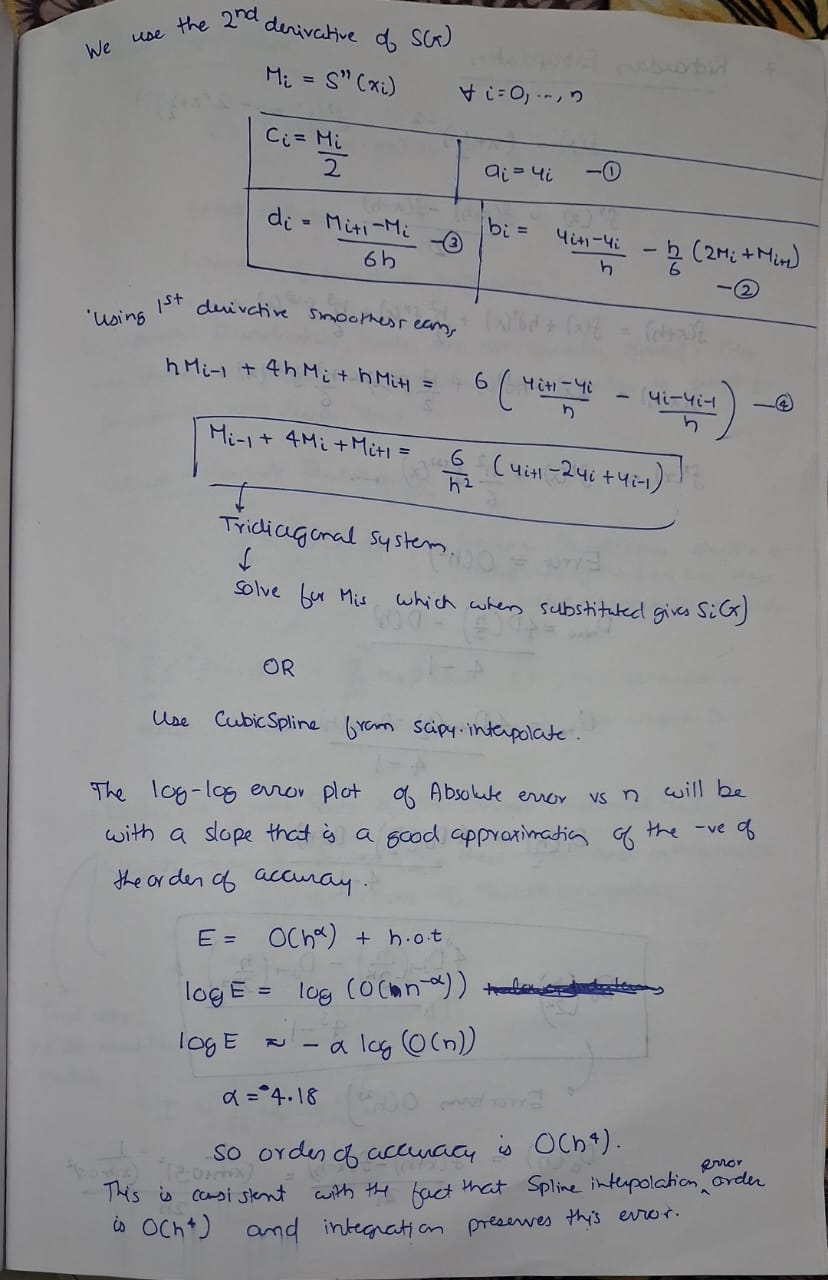

n =  4,  Spline Integral = 1.9986934198,  Error = 1.307e-03
n =  8,  Spline Integral = 1.9999302381,  Error = 6.976e-05
n = 16,  Spline Integral = 1.9999958152,  Error = 4.185e-06
n = 32,  Spline Integral = 1.9999997881,  Error = 2.119e-07


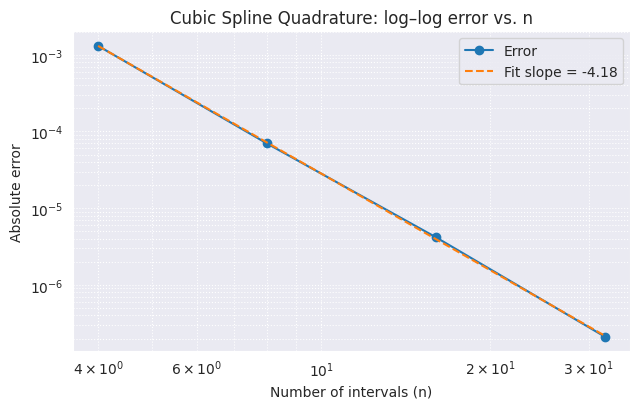


Estimated order of accuracy p ≈ 4.183


In [9]:
f = lambda x: np.sin(x)
I_true = 2.0  
a, b = 0, np.pi
n_values = [4, 8, 16, 32]
errors = []

for n in n_values:
    x = np.linspace(a, b, n + 1)
    y = f(x)
    spline = CubicSpline(x, y, bc_type='natural')
    I_spline, _ = quad(spline, a, b)
    error = abs(I_spline - I_true)
    errors.append(error)

    print(f"n = {n:2d},  Spline Integral = {I_spline:.10f},  Error = {error:.3e}")

n_values = np.array(n_values)
errors = np.array(errors)
p, c = np.polyfit(np.log(n_values), np.log(errors), 1)

# Plot log-log error vs n
plt.figure(figsize=(6.5, 4.2))
plt.loglog(n_values, errors, 'o-', label='Error')
plt.loglog(n_values, np.exp(c) * n_values**p, '--', label=f'Fit slope = {p:.2f}')
plt.xlabel('Number of intervals (n)')
plt.ylabel('Absolute error')
plt.title('Cubic Spline Quadrature: log–log error vs. n')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nEstimated order of accuracy p ≈ {-p:.3f}")

12. **Compare integration strategies**  
    $$
    I = \int_{-\infty}^{\infty} e^{-x^2} \cos(2x) dx
    $$  
    (a) Gauss–Hermite quadrature with 8 nodes  
    (b) Map the infinite domain using $ \xi = \tanh(ax) $ to a finite domain. Reformulate the integral in the new domain. Find integrand at $ \xi = \pm 1 $  
    (c) Plot $ f(x) $ with 17 uniform $ \xi $ points for $ a = 2 $ and $ a = 0.4 $. Which value of $a$ is more appropriate for mapping?
    
    (d) Use trapezoidal rule with $17$ points for $ a = 0.4 $ and $a=2$. Compare error with Simpson’s rule. Explain why trapezoidal rule performs better than Simpson's rule in this case. (HINT: Plot the integrand as a function of $\xi$ and note its behavior at the boundaries).

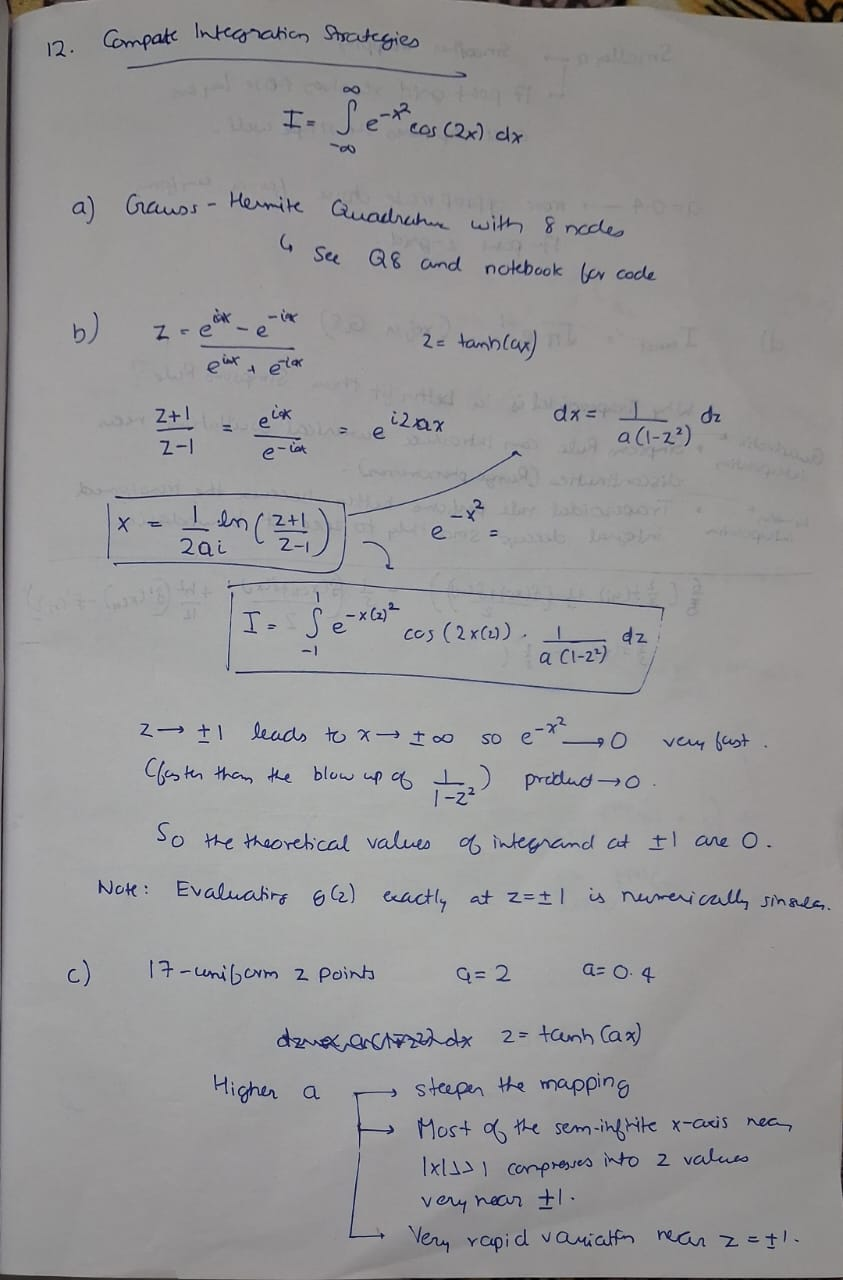

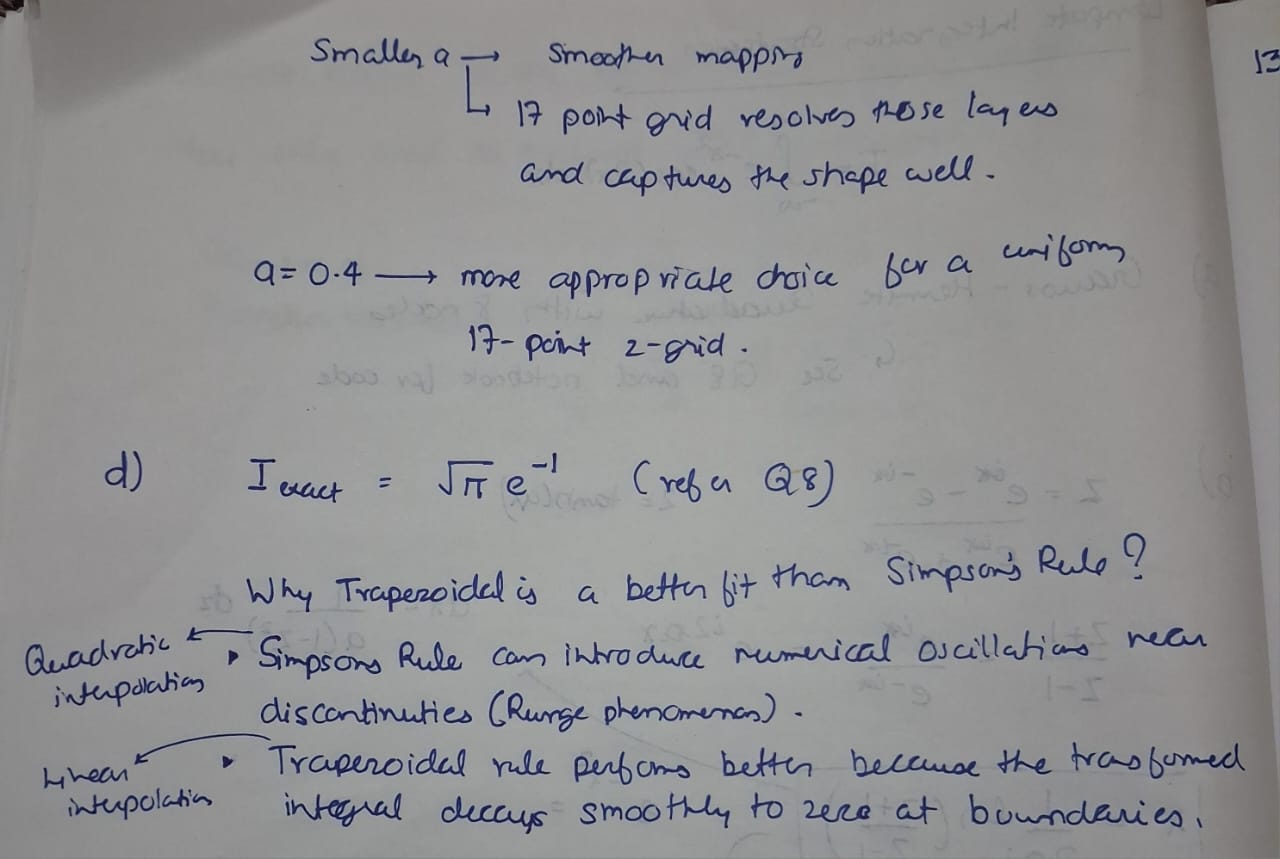

In [10]:
def gauss_hermite_integral(alpha, n=8):

    x, w = np.polynomial.hermite.hermgauss(n)
    fx = np.cos(alpha * x)
    approx = np.sum(w * fx)
    exact = sqrt(pi) * exp(-alpha**2 / 4)
    abs_error = abs(approx - exact)

    return approx, exact, abs_error


alpha = 2
pprox, exact, err = gauss_hermite_integral(alpha, n)
print(f"n = {n:<3d}  Approx = {approx:.8e}  Error = {err:.2e}")

n = 32   Approx = 3.42164087e-03  Error = 1.11e-16



a = 0.4
Trapezoidal: I = 6.520636e-01, error = 1.424e-05
Simpson:     I = 6.528885e-01, error = 8.392e-04

a = 2
Trapezoidal: I = 9.427161e-01, error = 2.907e-01
Simpson:     I = 9.354475e-01, error = 2.834e-01


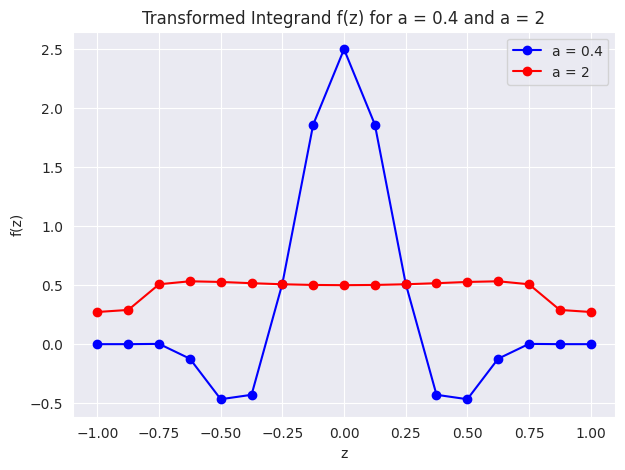

In [11]:
I_exact = np.sqrt(np.pi) * np.exp(-1)

def integrand(z, a):
    x = np.arctanh(z) / a
    dx_dz = 1 / (a * (1 - z**2))
    return np.exp(-x**2) * np.cos(2 * x) * dx_dz

def trapezoidal(y, z):
    return np.sum((y[1:] + y[:-1]) * np.diff(z) / 2)

def simpsons(y, z):
    n = len(z)
    h = (z[-1] - z[0]) / (n - 1)
    return (h / 3) * (y[0] + y[-1] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2]))

eps = 1e-6
N = 17
z = np.linspace(-1 + eps, 1 - eps, N)
sns.set_style('dark')
plt.figure(figsize=(7,5))
for a, color in zip([0.4, 2], ['b', 'r']):
    f = integrand(z, a)
    I_trap = trapezoidal(f, z)
    I_simp = simpsons(f, z)
    err_trap = abs(I_trap - I_exact)
    err_simp = abs(I_simp - I_exact)
    
    print(f"\na = {a}")
    print(f"Trapezoidal: I = {I_trap:.6e}, error = {err_trap:.3e}")
    print(f"Simpson:     I = {I_simp:.6e}, error = {err_simp:.3e}")
    plt.plot(z, f, 'o-', color=color, label=f'a = {a}')

plt.title('Transformed Integrand f(z) for a = 0.4 and a = 2')
plt.xlabel('z')
plt.ylabel('f(z)')
plt.grid(True)
plt.legend()
plt.show()


13. **Hybrid integration method**  
    Combine Simpson’s rule and trapezoidal rule with end correction to integrate  
    $$
    \int_{x_i-h}^{x_i+h} f(x) dx
    $$  
    using $ f(x_i \pm h), f(x_i), f'(x_i \pm h) $. What’s the order of accuracy for the scheme. Write out the global scheme for $\displaystyle \int_a^b f(x)dx$ based on this method?

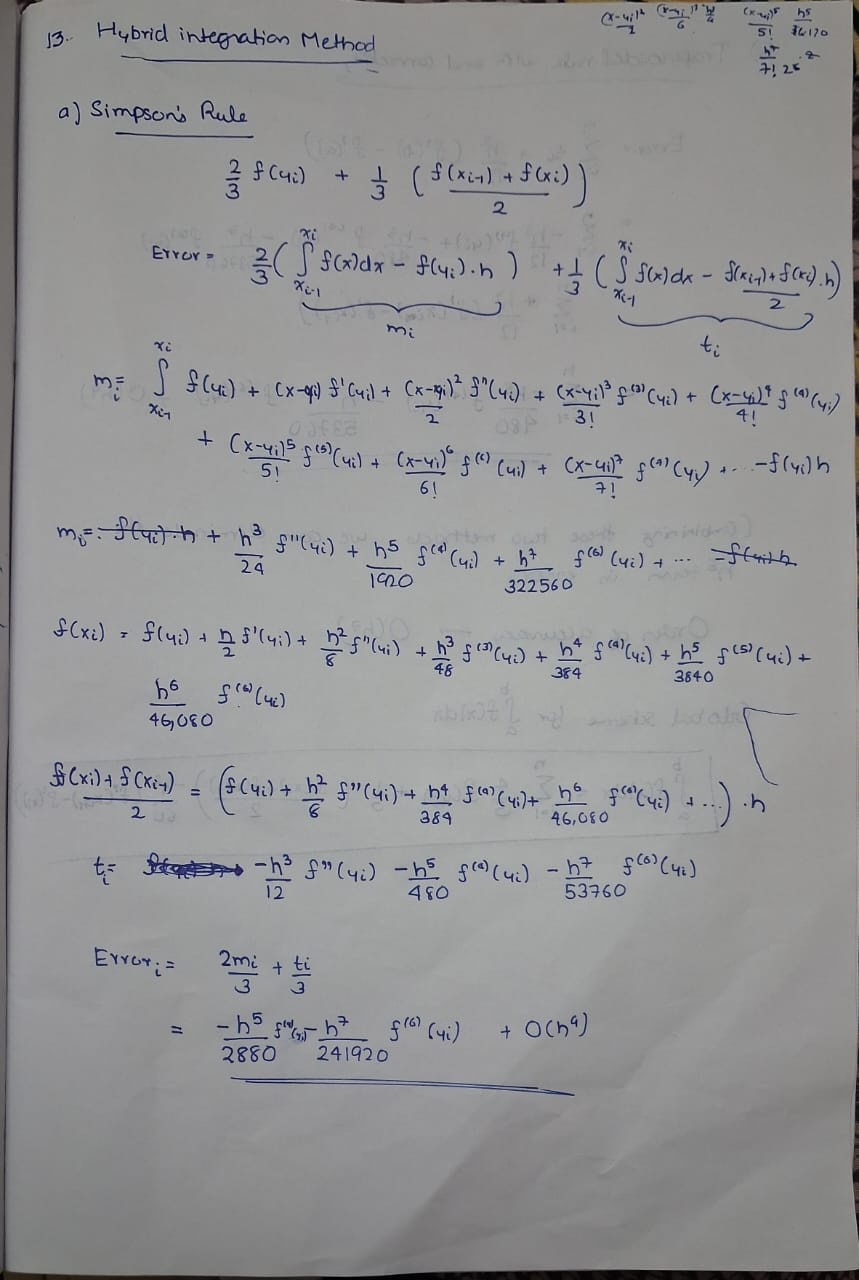

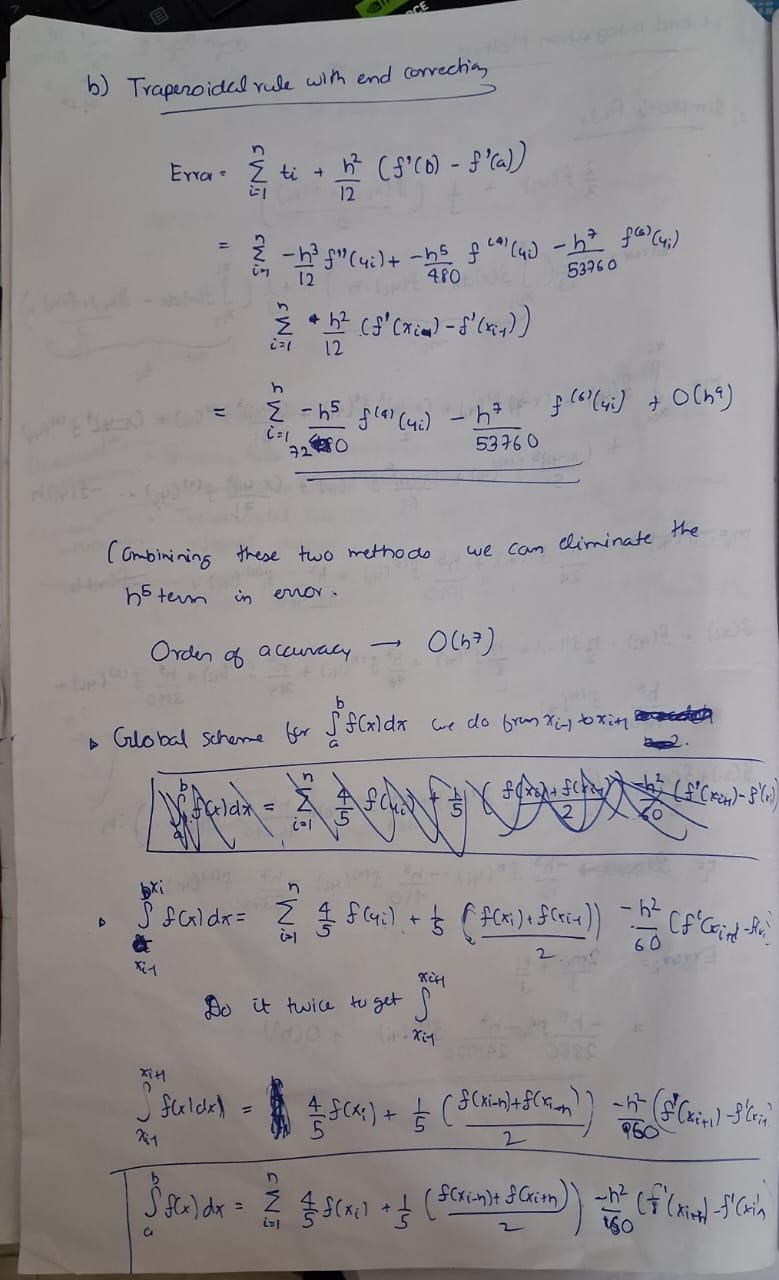